# W10 · Quantization robustness is a hypothesis / 量化穩健性仍是假說

**English.** The paper does not study quantization. This extension measures
post-training quantization (PTQ), but does not infer a mechanism from one run.
Every point below uses the **complete packed model size**: parameter payloads,
per-tensor/per-channel scales, tensor names/shapes, and container metadata.
The x-axis is bits per pixel/texel (bpp/bpt), not nominal bits per parameter.

**繁體中文.** 論文未研究量化。本延伸做 PTQ,但不從單次結果推論機制。每個點都計入
**完整封裝模型大小**:參數 payload、per-tensor/per-channel scale、tensor 名稱/shape
與容器 metadata。橫軸是每像素/texel 位元(bpp/bpt),不是名義 bits/parameter。

In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks': os.chdir('..')
sys.path.insert(0, os.path.abspath('.'))
import copy, csv, torch, numpy as np, matplotlib.pyplot as plt
from apps.image.data import load_image, image_to_coords_targets, find_kodak
from apps.image.build import build_grid, build_grid_peps
from peps.train import fit, TrainConfig, render_full, auto_device
from peps.metrics import psnr
from peps.quant import make_config, quantize_model
device = auto_device()
SEEDS = tuple(int(x) for x in os.getenv('PEPS_W10_SEEDS', '7,17,29').split(','))
STEPS = int(os.getenv('PEPS_W10_STEPS', '2500'))
SIZE_TOLERANCE_PCT = 2.5
print('device', device, '| seeds', SEEDS, '| steps', STEPS)

device cuda | seeds (7, 17, 29) | steps 2500


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


## 1. Match model size before training / 訓練前先配對模型大小
The grid baseline and concat PEPS use the same feature width. We choose the
PEPS grid resolution whose **total parameter count** is closest to the baseline.
After quantization we independently check packed-bit size; only pairs within
2.5% are eligible evidence. `grid` is not labeled RTXNTC/NTC_N.

Grid baseline 與 concat PEPS 使用相同 feature width,並選出總參數最接近 baseline
的 PEPS grid resolution。量化後再以完整封裝 bits 檢查;差距 2.5% 內才可比較。

In [2]:
BASE_RES, FEATURE_DIM, NUM_FREQ = 128, 8, 6
_, TARGET_PARAMS = build_grid(BASE_RES, FEATURE_DIM)
def peps_candidate(res):
    return build_grid_peps(res, FEATURE_DIM, NUM_FREQ, 'concat')
PEPS_RES, PEPS_PARAMS = min(
    ((r, peps_candidate(r)[1]) for r in range(96, 145)),
    key=lambda item: abs(item[1] - TARGET_PARAMS),
)
PARAM_GAP_PCT = 100 * abs(PEPS_PARAMS - TARGET_PARAMS) / TARGET_PARAMS
print(dict(grid_resolution=BASE_RES, grid_params=TARGET_PARAMS,
           peps_resolution=PEPS_RES, peps_params=PEPS_PARAMS,
           parameter_gap_pct=round(PARAM_GAP_PCT, 3)))

{'grid_resolution': 128, 'grid_params': 140163, 'peps_resolution': 125, 'peps_params': 140235, 'parameter_gap_pct': 0.051}


## 2. Train three matched pairs / 訓練三組配對 seed

In [3]:
img = load_image(find_kodak(1), max_size=384)
coords, targets, (H, W) = image_to_coords_targets(img)
def train(builder_out, seed):
    torch.manual_seed(seed)
    model, pc = builder_out
    fit(model, coords, targets, TrainConfig(steps=STEPS, batch_size=32768,
        lr=1e-2, device=device))
    return model, pc
def eval_psnr(m):
    pred = render_full(m, coords, device=device).reshape(H, W, 3).clamp(0, 1)
    return psnr(pred, img)
trained = {}
for seed in SEEDS:
    grid_model, grid_pc = train(build_grid(BASE_RES, FEATURE_DIM), seed)
    peps_model, peps_pc = train(peps_candidate(PEPS_RES), seed)
    trained[seed] = {'grid': (grid_model, grid_pc), 'peps': (peps_model, peps_pc)}
    print(seed, 'grid', round(eval_psnr(grid_model), 3),
          '| peps', round(eval_psnr(peps_model), 3))

7 grid 40.398 | peps 42.347


17 grid 40.022 | peps 41.891


29 grid 37.72 | peps 41.827


## 3. PTQ ablations / PTQ 消融
- `fp32`: unquantized reference
- `int8_per_tensor`: one scale per parameter tensor
- `int8_per_channel`: feature/output-channel scales
- `mixed_l6_w8_pc`: 6-bit latent + per-channel 8-bit weights

Biases remain fp32 in every weight-only PTQ plan. The report counts them.

In [4]:
PLANS = {
    'fp32': make_config(latent_bits=32, weight_bits=32, bias_bits=32),
    'int8_per_tensor': make_config(latent_bits=8, weight_bits=8, bias_bits=32),
    'int8_per_channel': make_config(
        latent_bits=8, weight_bits=8, bias_bits=32,
        latent_granularity='per_channel', weight_granularity='per_channel'),
    'mixed_l6_w8_pc': make_config(
        latent_bits=6, weight_bits=8, bias_bits=32,
        latent_granularity='per_tensor', weight_granularity='per_channel'),
}
PLAN_FIELDS = {
    'fp32': (32, 32, 32, 'per_tensor', 'per_tensor'),
    'int8_per_tensor': (8, 8, 32, 'per_tensor', 'per_tensor'),
    'int8_per_channel': (8, 8, 32, 'per_channel', 'per_channel'),
    'mixed_l6_w8_pc': (6, 8, 32, 'per_tensor', 'per_channel'),
}
rows = []
for seed, pair in trained.items():
    for ablation, config in PLANS.items():
        pair_rows = []
        for method, (model, model_params) in pair.items():
            candidate = copy.deepcopy(model)
            metrics = quantize_model(candidate, config=config,
                num_pixels=H * W, num_texels=H * W)
            lb, wb, bb, lg, wg = PLAN_FIELDS[ablation]
            row = dict(schema_version=2, run_id=f'w10-s{seed}-{method}-{ablation}',
                source_kind='repeated_matched_run', legacy_method_label='',
                nominal_payload_bits_per_parameter='',
                seed=seed, profile='course_fast', method=method,
                train_steps=STEPS, model_params=model_params, ablation=ablation,
                latent_bits=lb, weight_bits=wb, bias_bits=bb,
                latent_granularity=lg, weight_granularity=wg,
                payload_bits=metrics['payload_bits'], scale_bits=metrics['scale_bits'],
                metadata_bits=metrics['metadata_bits'],
                total_encoded_bits=metrics['total_encoded_bits'],
                total_encoded_bytes=metrics['total_encoded_bytes'],
                bits_per_parameter=f"{metrics['bits_per_parameter']:.8f}",
                bits_per_pixel=f"{metrics['bpp']:.8f}",
                bits_per_texel=f"{metrics['bpt']:.8f}",
                psnr_db=f'{eval_psnr(candidate):.6f}')
            pair_rows.append(row)
        size_gap = 100 * abs(pair_rows[0]['total_encoded_bits'] -
                             pair_rows[1]['total_encoded_bits']) / max(
                             pair_rows[0]['total_encoded_bits'],
                             pair_rows[1]['total_encoded_bits'])
        matched = size_gap <= SIZE_TOLERANCE_PCT
        for row in pair_rows:
            row['paired_size_gap_pct'] = f'{size_gap:.6f}'
            row['matched_size'] = str(matched).lower()
            row['claim_status'] = 'hypothesis_pending_repeated_matched_size'
            rows.append(row)
print('rows', len(rows), '| matched pairs',
      sum(r['matched_size'] == 'true' for r in rows) // 2)

rows 24 | matched pairs 12


## 4. Persist the auditable table / 寫出可稽核結果

In [5]:
CSV_PATH = 'results/w10_rate_distortion.csv'
FIELDS = ['schema_version','run_id','source_kind','legacy_method_label',
          'nominal_payload_bits_per_parameter','seed','profile','method','train_steps',
          'model_params','ablation','latent_bits','weight_bits','bias_bits',
          'latent_granularity','weight_granularity','payload_bits','scale_bits',
          'metadata_bits','total_encoded_bits','total_encoded_bytes',
          'bits_per_parameter','bits_per_pixel','bits_per_texel','psnr_db',
          'paired_size_gap_pct','matched_size','claim_status']
os.makedirs('results', exist_ok=True)
with open(CSV_PATH, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=FIELDS, lineterminator='\n')
    writer.writeheader(); writer.writerows(rows)
print('saved', CSV_PATH)

saved results/w10_rate_distortion.csv


## 5. Rate-distortion and paired gaps / 率失真與配對差距
Lines are descriptive. A claim requires every compared plan to pass the size
tolerance for all seeds, plus confidence intervals from repeated matched runs.

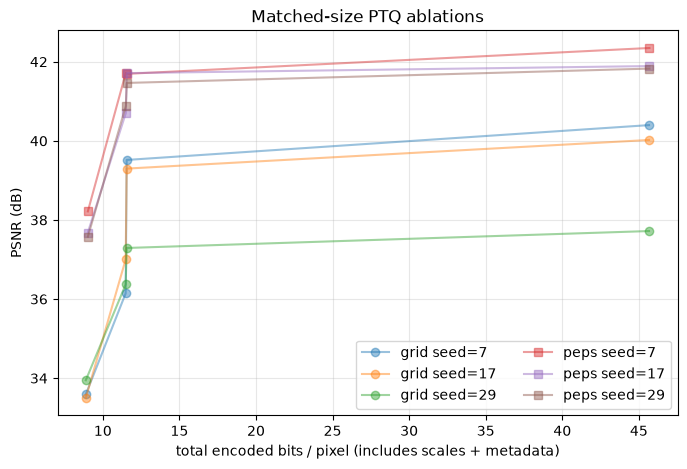

fp32 eligible paired gaps: [1.9497, 1.8685, 4.107]
int8_per_tensor eligible paired gaps: [5.5725, 3.7008, 4.5091]
int8_per_channel eligible paired gaps: [2.1769, 2.4136, 4.1725]
mixed_l6_w8_pc eligible paired gaps: [4.6283, 4.1831, 3.6282]


In [6]:
plt.figure(figsize=(8, 5))
for method, marker in [('grid', 'o'), ('peps', 's')]:
    for seed in SEEDS:
        subset = [r for r in rows if r['method'] == method and r['seed'] == seed]
        subset.sort(key=lambda r: float(r['bits_per_pixel']))
        plt.plot([float(r['bits_per_pixel']) for r in subset],
                 [float(r['psnr_db']) for r in subset], marker=marker, alpha=.45,
                 label=f'{method} seed={seed}')
plt.xlabel('total encoded bits / pixel (includes scales + metadata)')
plt.ylabel('PSNR (dB)'); plt.title('Matched-size PTQ ablations')
plt.grid(True, alpha=.3); plt.legend(ncol=2); plt.show()

for ablation in PLANS:
    pairs = []
    for seed in SEEDS:
        selected = [r for r in rows if r['seed'] == seed and
                    r['ablation'] == ablation and r['matched_size'] == 'true']
        if len(selected) == 2:
            scores = {r['method']: float(r['psnr_db']) for r in selected}
            pairs.append(scores['peps'] - scores['grid'])
    print(ablation, 'eligible paired gaps:', [round(x, 4) for x in pairs])

## 6. Interpretation boundary / 解讀邊界
**Hypothesis only:** sampling a shared grid at projected points may change PTQ
sensitivity. The earlier single-seed, unmatched-size run cannot establish that
cause. Promote this to a result only after repeated matched-encoded-size runs
show a stable paired effect; then report uncertainty and failures as well.

**僅是假說:** projected-point shared-grid sampling 可能改變 PTQ 敏感度。先前單 seed、
未配對大小的實驗不能建立因果。只有多次 matched-encoded-size 配對結果穩定,並報告
不確定性與失敗案例後,才能升級為研究結論。